In [106]:
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
import folium

In [179]:
df = pd.read_csv('Dataset/london_crime_by_lsoa.csv')

In [28]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13490604 entries, 0 to 13490603
Data columns (total 7 columns):
 #   Column          Dtype 
---  ------          ----- 
 0   lsoa_code       object
 1   borough         object
 2   major_category  object
 3   minor_category  object
 4   value           int64 
 5   year            int64 
 6   month           int64 
dtypes: int64(3), object(4)
memory usage: 720.5+ MB


,lsoa_code,borough,major_category,minor_category,value,year,month
0,E01001116,Croydon,Burglary,Burglary in Other Buildings,0,2016,11
1,E01001646,Greenwich,Violence Against the Person,Other violence,0,2016,11
2,E01000677,Bromley,Violence Against the Person,Other violence,0,2015,5
3,E01003774,Redbridge,Burglary,Burglary in Other Buildings,0,2016,3
4,E01004563,Wandsworth,Robbery,Personal Property,0,2008,6


Area Chart

In [25]:
area_df = df.groupby("year", sort=True)["value"].sum()
area_df = area_df.reset_index()
area_df.columns.values[1] = "value"
area_df.head()


,year,value
0,2008,738641
1,2009,717214
2,2010,715324
3,2011,724915
4,2012,737329


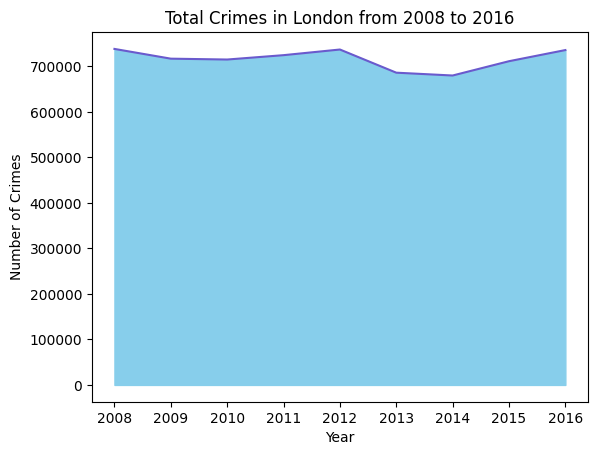

In [27]:
plt.fill_between(area_df['year'], area_df['value'], color="skyblue")
plt.plot(area_df['year'], area_df['value'], color="Slateblue")
plt.ylabel("Number of Crimes")
plt.xlabel("Year")
plt.title("Total Crimes in London from 2008 to 2016")
plt.show()

Histogram Chart

In [207]:
hist_df = df.loc[(df["year"] == 2016) & (df["month"] == 11)]
hist_df = hist_df.loc[(df["lsoa_code"] == "E01000001") | 
                      (df["lsoa_code"] == "E01000002") | 
                      (df["lsoa_code"] == "E01000003") | 
                      (df["lsoa_code"] == "E01000004") | 
                      (df["lsoa_code"] == "E01000005")]
hist_df = hist_df["lsoa_code"].sort_values()
hist_df = hist_df.reset_index().drop(columns="index")
hist_df["lsoa_code"] = hist_df["lsoa_code"].str[-1:]
hist_df.head()

,lsoa_code
0,1
1,1
2,1
3,1
4,1


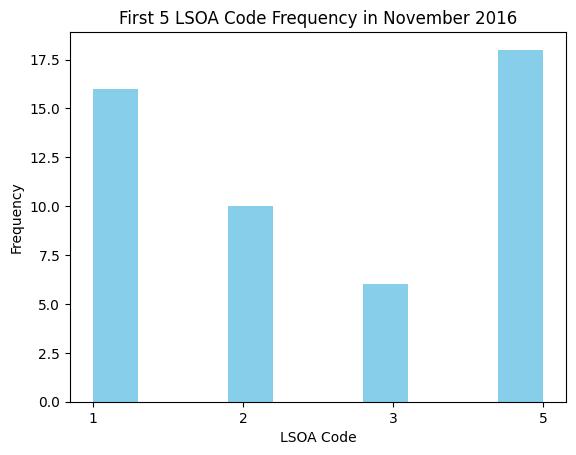

In [208]:
plt.hist(hist_df["lsoa_code"], color="skyblue")
plt.ylabel("Frequency")
plt.xlabel("LSOA Code")
plt.title("First 5 LSOA Code Frequency in November 2016")
plt.show()

Bar Chart

In [66]:
bar_df = df.groupby("borough", sort=True)["value"].sum()
bar_df = bar_df.reset_index()
bar_df.columns.values[1] = "value"
bar_df.sort_values("value", ascending=False, inplace=True)
limit_df = bar_df.iloc[:10]
limit_df = limit_df.reset_index()
limit_df = limit_df.drop(columns="index")
limit_df.head()

,borough,value
0,Westminster,455028
1,Lambeth,292178
2,Southwark,278809
3,Camden,275147
4,Newham,262024


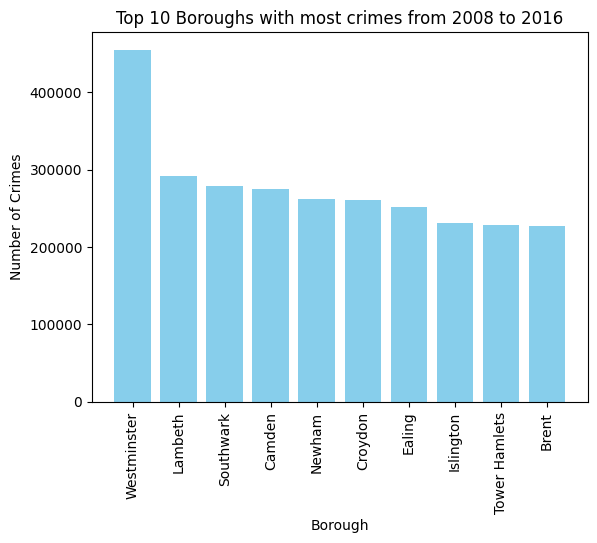

In [67]:
plt.bar(limit_df['borough'], limit_df['value'], color="skyblue")
plt.ylabel("Number of Crimes")
plt.xlabel("Borough")
plt.xticks(rotation=90)
plt.title("Top 10 Boroughs with most crimes from 2008 to 2016")
plt.show()

Pie Chart

In [75]:
pie_df = df.loc[df["borough"] == "Westminster"]
pie_df = pie_df.groupby("major_category", sort=True)["value"].sum()
pie_df = pie_df.reset_index()
pie_df.columns.values[1] = "value"
pie_df.info()
pie_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   major_category  9 non-null      object
 1   value           9 non-null      int64 
dtypes: int64(1), object(1)
memory usage: 276.0+ bytes


,major_category,value
0,Burglary,29295
1,Criminal Damage,20405
2,Drugs,34031
3,Fraud or Forgery,273
4,Other Notifiable Offences,6148


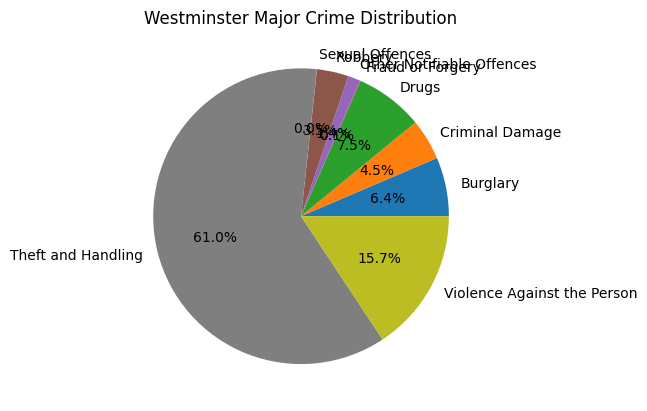

In [76]:
plt.pie(pie_df["value"], labels=pie_df["major_category"], autopct="%1.1f%%")
plt.title("Westminster Major Crime Distribution")
plt.show()

Box Plot

In [89]:
box_df = df.groupby(["year", "month"], sort=True)["value"].sum()
box_df = box_df.reset_index()
box_df.info()
box_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   year    108 non-null    int64
 1   month   108 non-null    int64
 2   value   108 non-null    int64
dtypes: int64(3)
memory usage: 2.7 KB


,year,month,value
0,2008,1,65419
1,2008,2,62626
2,2008,3,61343
3,2008,4,59640
4,2008,5,62587


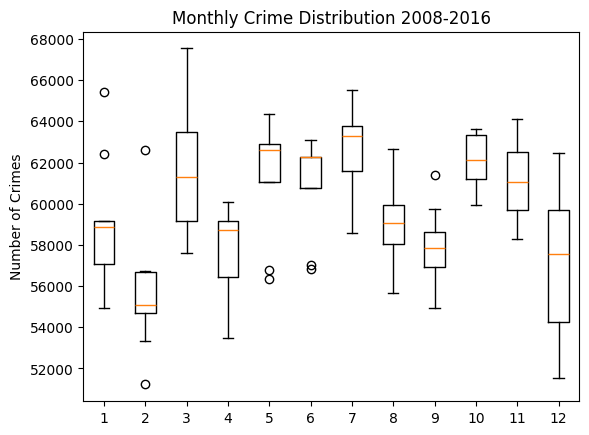

In [91]:
plt.boxplot([box_df[box_df["month"]==1]["value"], 
             box_df[box_df["month"]==2]["value"], 
             box_df[box_df["month"]==3]["value"], 
             box_df[box_df["month"]==4]["value"], 
             box_df[box_df["month"]==5]["value"], 
             box_df[box_df["month"]==6]["value"], 
             box_df[box_df["month"]==7]["value"], 
             box_df[box_df["month"]==8]["value"], 
             box_df[box_df["month"]==9]["value"], 
             box_df[box_df["month"]==10]["value"], 
             box_df[box_df["month"]==11]["value"], 
             box_df[box_df["month"]==12]["value"]])
plt.ylabel("Number of Crimes")
plt.title("Monthly Crime Distribution 2008-2016")
plt.show()

Scatter Plot

Word Clouds

In [101]:
stopwords = set(STOPWORDS)
text = pd.read_csv('Dataset/london_crime_by_lsoa.csv', usecols=["minor_category"])

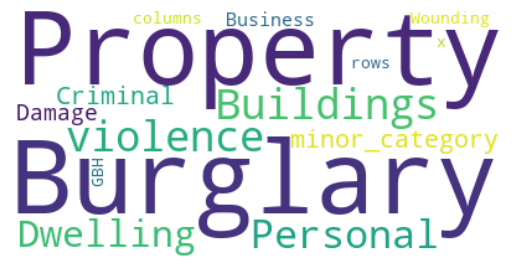

In [105]:
words = WordCloud(background_color="white", stopwords=stopwords).generate(str(text))
plt.imshow(words, interpolation="bilinear")
plt.axis("off")
plt.show()

Folium Maps

In [107]:
london_map = folium.Map(location=[51.5074, 0.1278], zoom_start=10)
london_map